**In this Notebook we will do the following:**

- Construct the Pauli-Transfer-Matrix (PTM) of multiple Circuits
    - Memory Round: Surface Code
    - Lattice Surgery

- Invert the PTM to get an estimate of the Logical Operator

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

repo_root = pathlib.Path.cwd()

repo_root = repo_root.parent.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /home/ubuntu/qecsim


In [3]:
from src.core.data_models import NoiseParameters
from src.tools.qem_estimator.logical_level.calc_ptm import PTMCalculator
from src.core.data_models import PTMCircuits
from src.codes.lattice_surgery.builder import SurgeryBuilder
from itertools import product
from tqdm import tqdm
import gc

import stim

**PTM Calculation: Lattice Surgery**

**Logical-Estimator**

We now use the Noisy and the Ideal PTM in order to build the logical estimator

**Overhead-Factor/ Physical Error Probability**

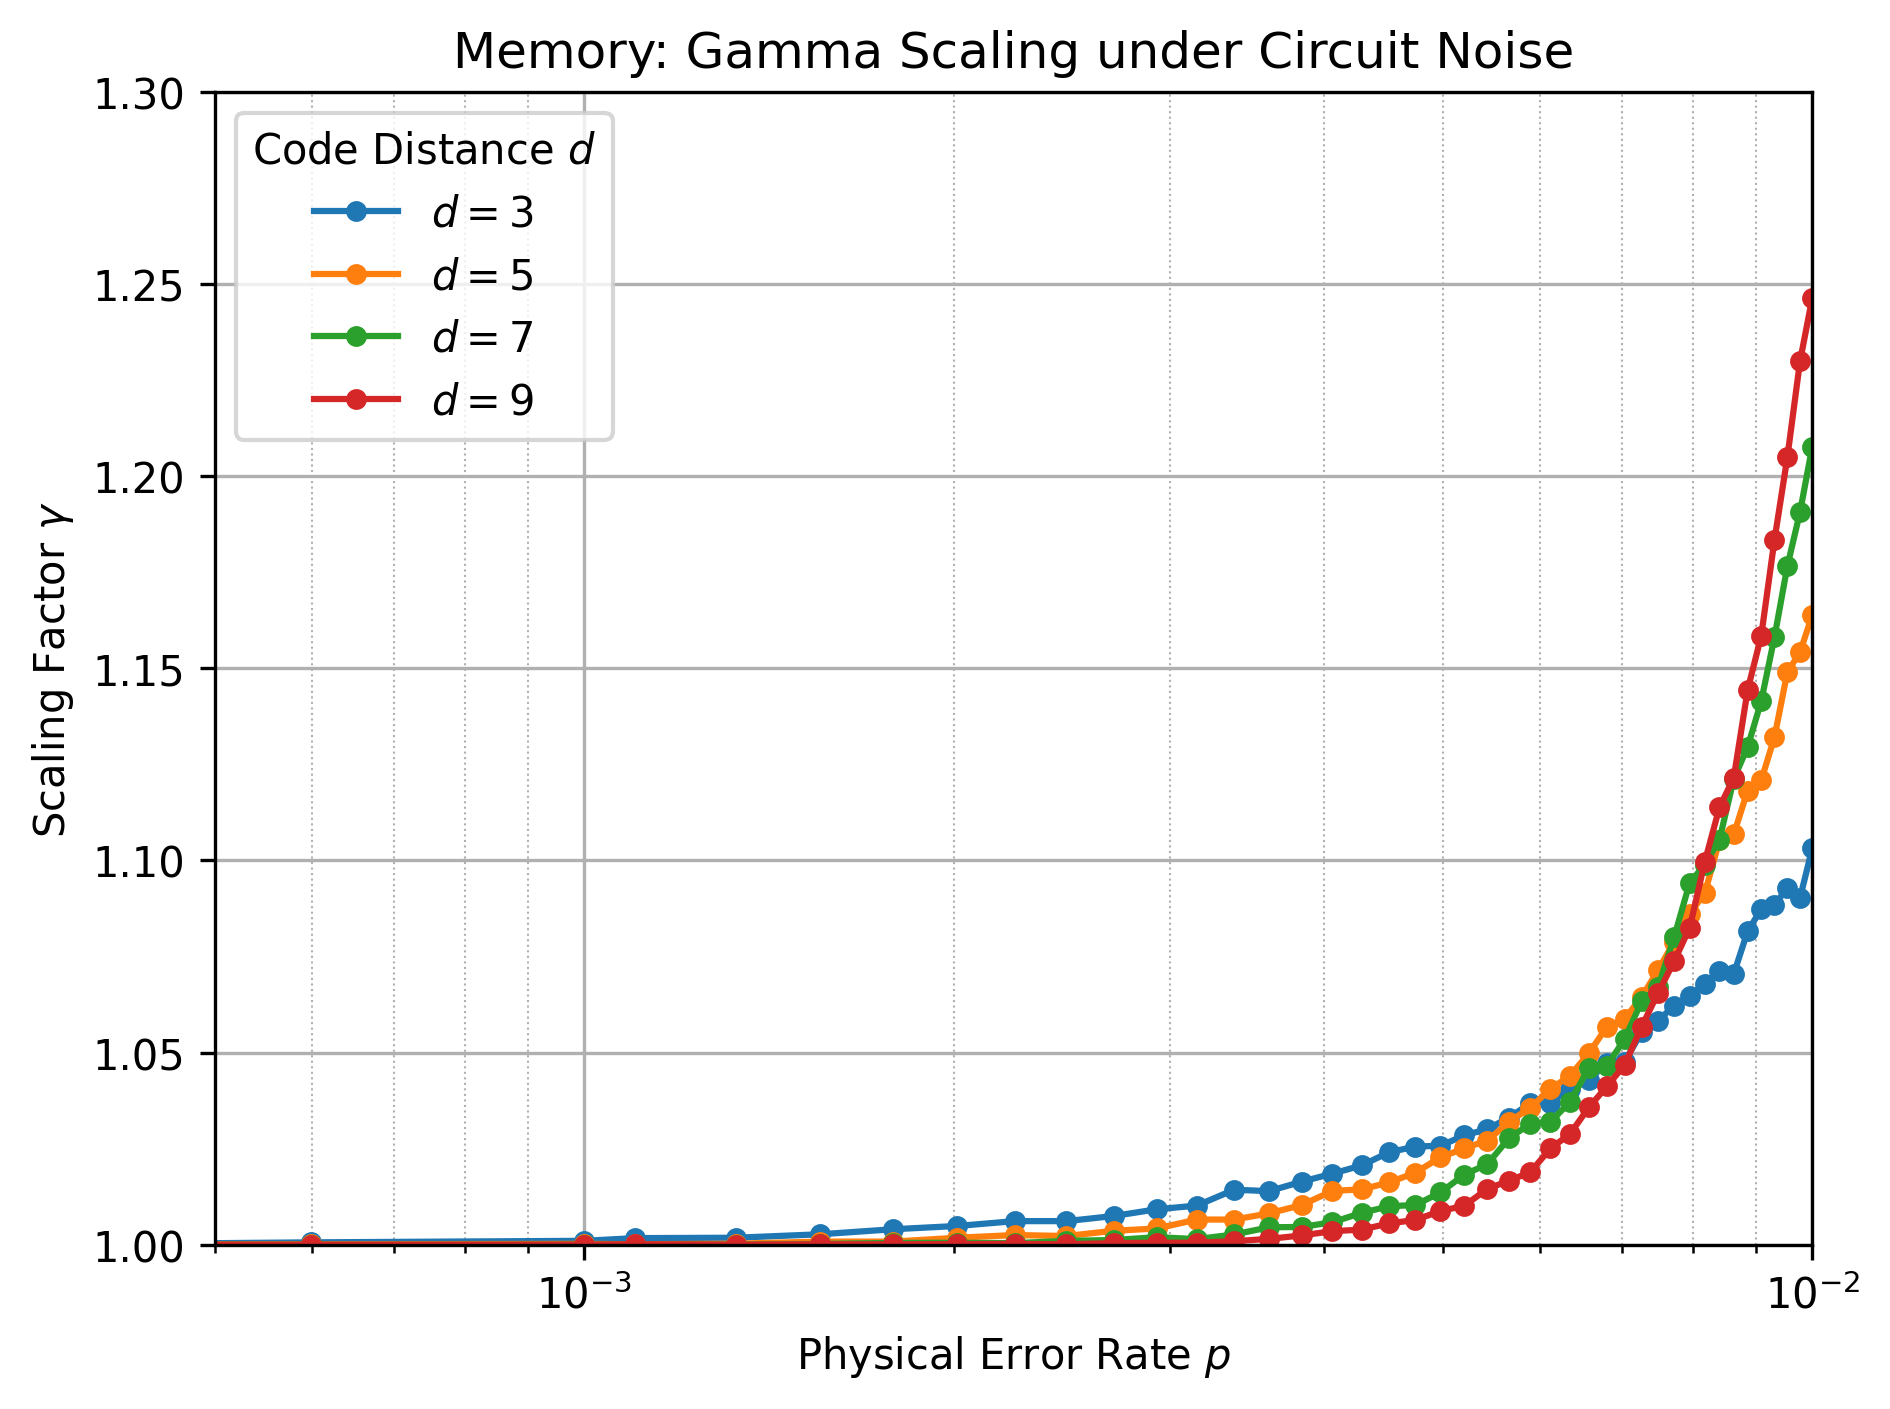

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('../data/gamma_memory.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1)

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4,
        label=r"$d={}$".format(distance)
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 1.3)
ax.set_xlim(5e-4, 1e-2)
ax.set_xscale('log') 
ax.set_title("Memory: Gamma Scaling under Circuit Noise")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"Scaling Factor $\gamma$")

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle=':', linewidth=0.5)

# Moved legend to upper right to avoid the inset box
ax.legend(title="Code Distance $d$", loc='upper left')

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../data/gamma_memory_d3579.pdf", bbox_inches='tight')

plt.show()

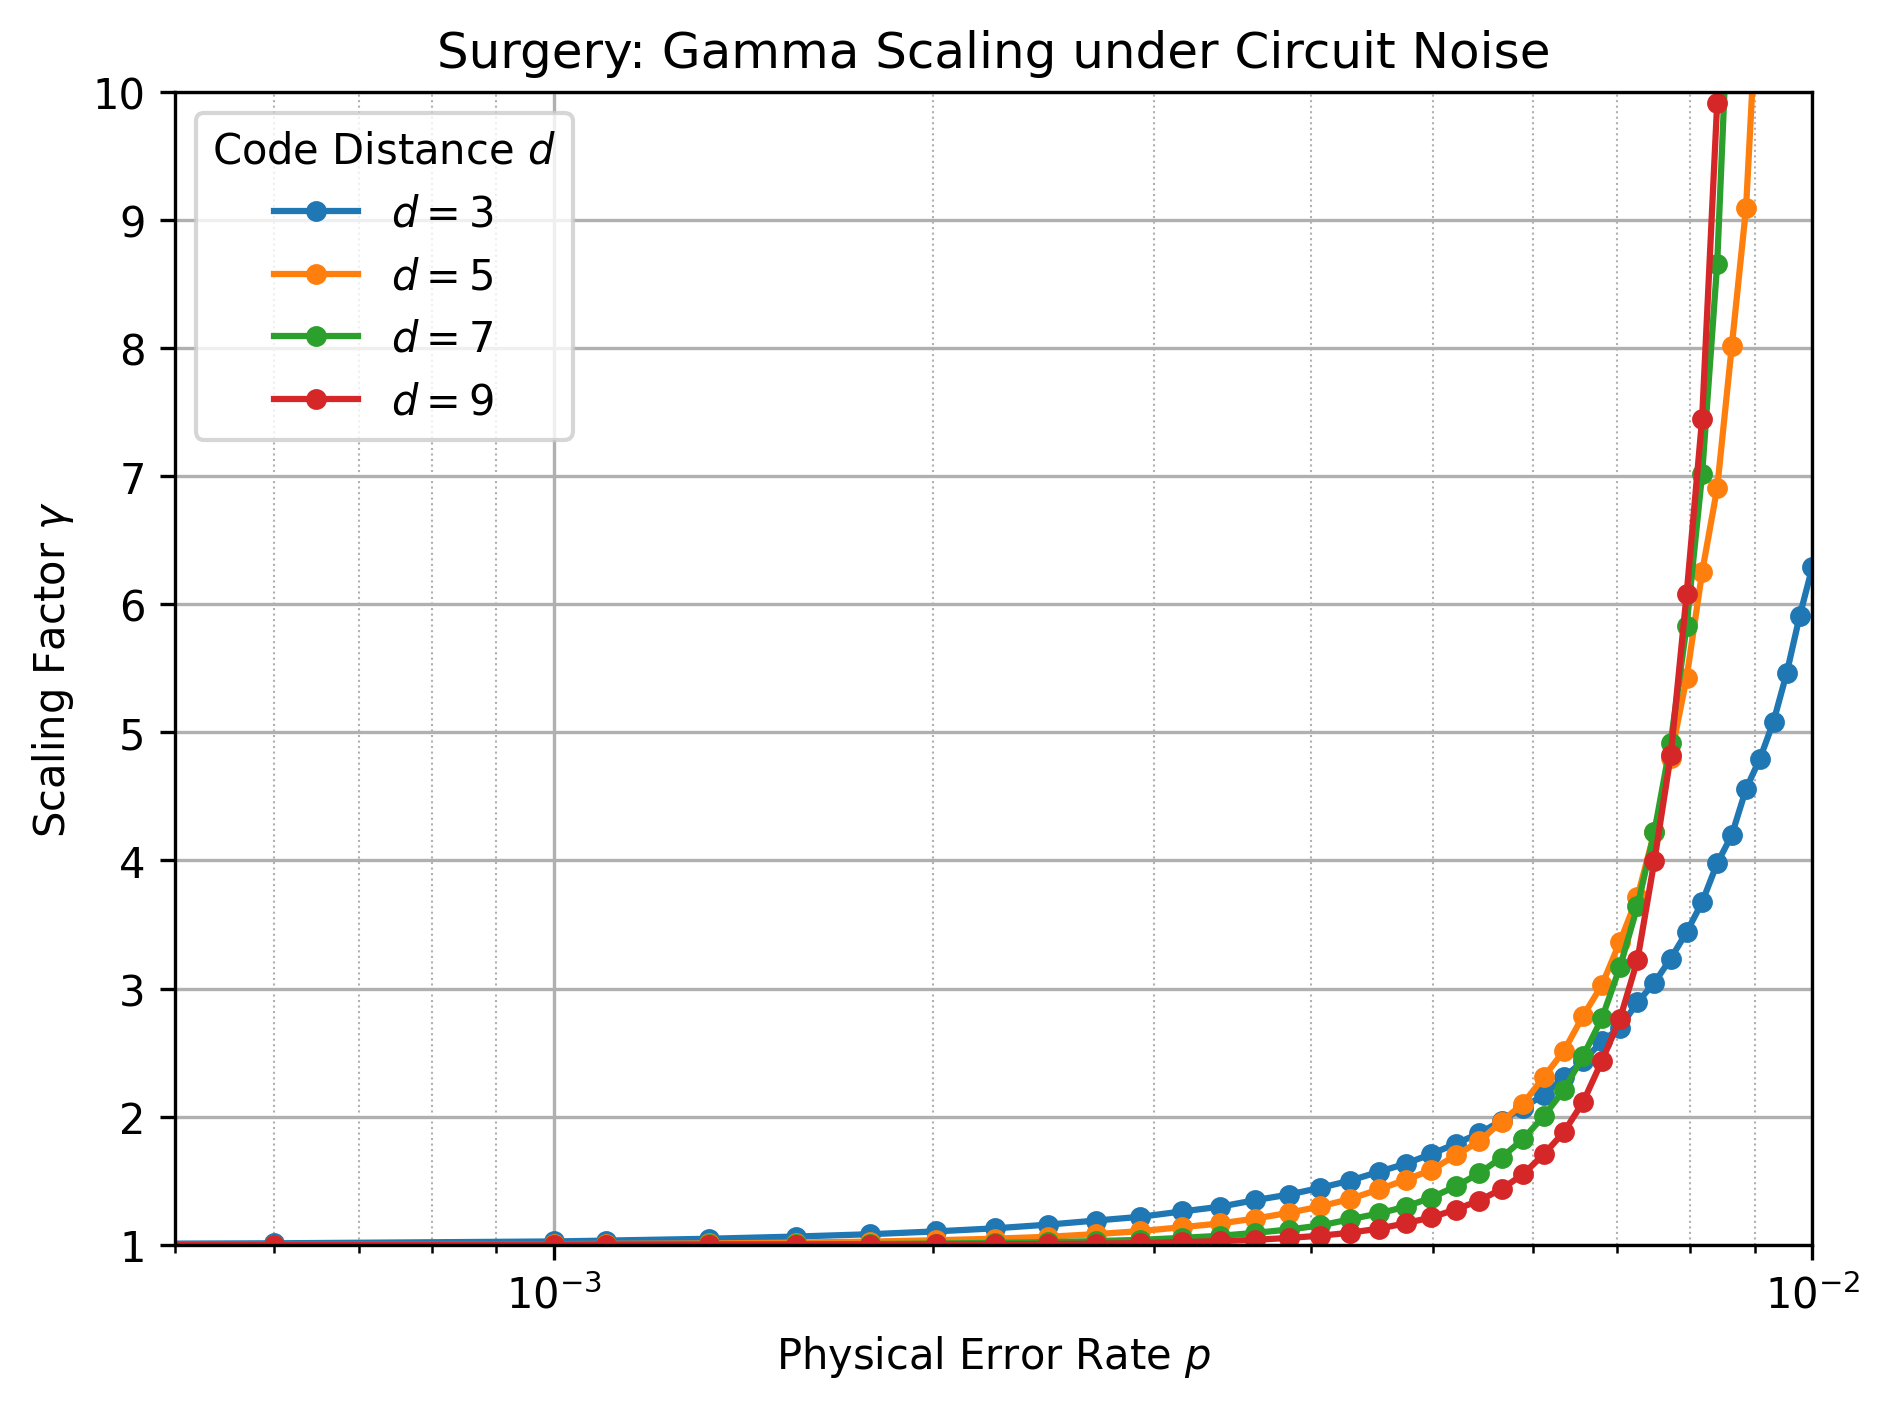

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('../data/gamma_surgery.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1)

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4,
        label=r"$d={}$".format(distance)
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 10.0)
ax.set_xlim(5e-4, 1e-2)
ax.set_xscale('log') 
ax.set_title("Surgery: Gamma Scaling under Circuit Noise")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"Scaling Factor $\gamma$")

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle=':', linewidth=0.5)

# Moved legend to upper right to avoid the inset box
ax.legend(title="Code Distance $d$", loc='upper left')

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../data/gamma_surgery_d3579.pdf", bbox_inches='tight')

plt.show()

In [6]:
import numpy as np

In [7]:
# Calculate the infidelities around the threshold for the d=5,7 memory cases

# Load the matrices for d=5 and d=7
ptm_d5_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d7_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
probs = np.linspace(1.1e-3, 1e-2, 40)
ptm_d5_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1


    fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 4
    return 1 - fidelity

# Calculate infidelities for d=5 and d=7
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]

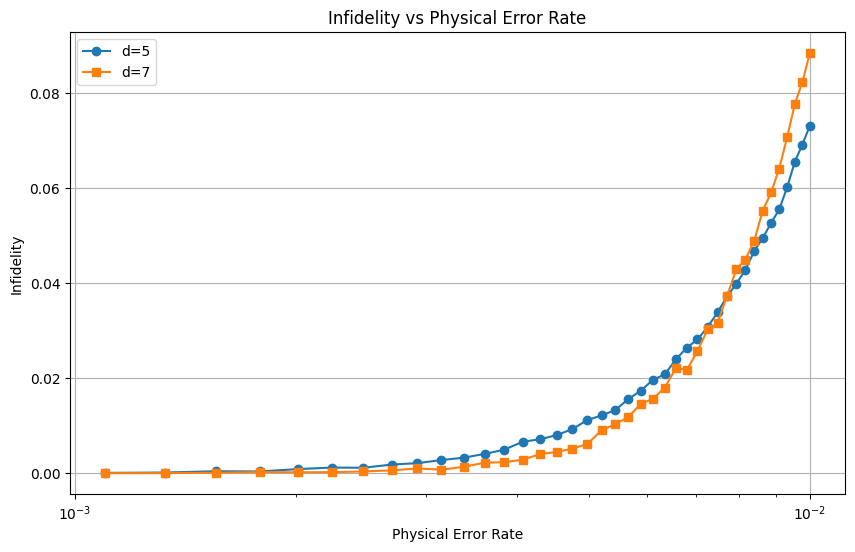

In [8]:
# Plotting infidelity vs physical error rate
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(probs, infidelities_d5, 'o-', label='d=5')
plt.plot(probs, infidelities_d7, 's-', label='d=7')
plt.xscale('log')
plt.xlabel('Physical Error Rate')
plt.ylabel('Infidelity')
plt.title('Infidelity vs Physical Error Rate')
plt.legend()
plt.grid(True)

# Save plot as PDF
plt.savefig("../data/Memory_infidelity_vs_physical_error_rate.pdf", bbox_inches='tight')

# Show the plot
plt.show()

In [9]:
# Calculate the infidelities around the threshold for the d=5,7 memory cases

# Load the matrices for d=5 and d=7
ptm_d5_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d7_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
probs = np.linspace(1.1e-3, 1e-2, 40)
ptm_d5_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1


    fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 16
    return 1 - fidelity

# Calculate infidelities for d=5 and d=7
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]

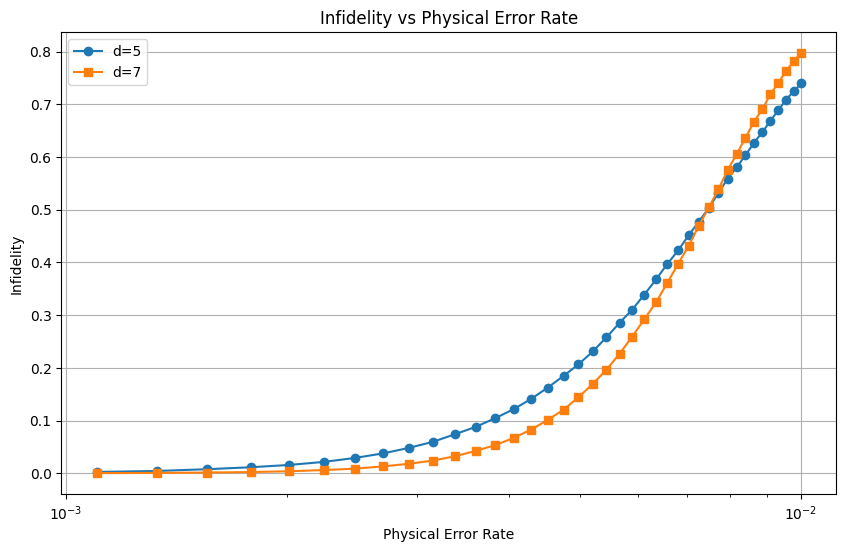

In [10]:
# Plotting infidelity vs physical error rate
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(probs, infidelities_d5, 'o-', label='d=5')
plt.plot(probs, infidelities_d7, 's-', label='d=7')
plt.xscale('log')
plt.xlabel('Physical Error Rate')
plt.ylabel('Infidelity')
plt.title('Infidelity vs Physical Error Rate')
plt.legend()
plt.grid(True)

# Save plot as PDF
plt.savefig("../data/Surgery_infidelity_vs_physical_error_rate.pdf", bbox_inches='tight')

# Show the plot
plt.show()